<a href="https://colab.research.google.com/github/junaidshaikh2004/AIDS_Sem8_RL/blob/main/RL_Exp_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Junaid Shaikh  | 48 | 221A052

Upper Confidence Bound (UCB1): Selects actions based on both the estimated reward and uncertainty

In [1]:
print("Junaid Shaikh  | 48 | 221A052")
import numpy as np
import matplotlib.pyplot as plt


Junaid Shaikh  | 48 | 221A052


Step 1: To create multiArmedBandit Class

In [2]:
print("Junaid Shaikh  | 48 | 221A052")
class MultiArmedBandit:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k) #True rewards for each arm
        self.best_arm = np.argmax(self.q_true)

    def pull_arm(self, arm):
        return np.random.normal(self.q_true[arm], 1) #Reward with some noise

Junaid Shaikh  | 48 | 221A052


Step 2: To create agent Class

In [3]:
print("Junaid Shaikh  | 48 | 221A052")
class Agent:
    def __init__(self, bandit, strategy="epsilon_greedy", epsilon=0.1, c=2):
        self.bandit = bandit
        self.strategy = strategy
        self.epsilon = epsilon
        self.c = c
        self.k = bandit.k
        self.Q = np.zeros(self.k) #Estimated rewards
        self.N = np.zeros(self.k) # Number of times each arm was pulled

    def select_action(self, t):
      if self.strategy == "epsilon_greedy":
        if np.random.rand() < self.epsilon:
          return np.random.randint(self.k) #Random action
        return np.argmax(self.Q) #Exploit best-known action

      elif self.strategy == "ucb1":
        if 0 in self.N: #Ensure all arms are tried at least once
              return np.argmin(self.N)
        return np.argmax(self.Q + self.c * np.sqrt(np.log(t + 1) / self.N))

    def update(self, arm, reward):
      self.N[arm] += 1
      self.Q[arm] += (reward - self.Q[arm]) / self.N[arm] #Incremental mean update





Junaid Shaikh  | 48 | 221A052


Implements Epsilon-Greedy, and UCB1 exploration agents

Updates Q-values using incremental mean method

Step 3: To create function to estimate average reward for each strategy

In [4]:
print("Junaid Shaikh  | 48 | 221A052")
def run_strategy(k=10, steps=1000, runs=200, strategies=["epsilon_greedy", "ucb1"]):
    avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}

    for strategy in strategies:
        for run in range(runs):
            bandit = MultiArmedBandit(k)
            agent = Agent(bandit, strategy=strategy)

            rewards = np.zeros(steps)
            for t in range(steps):
              action = agent.select_action(t)
              reward = bandit.pull_arm(action)
              agent.update(action, reward)
              rewards[t] = reward

        avg_rewards[strategy] += rewards / runs

    return avg_rewards


Junaid Shaikh  | 48 | 221A052


Runs multiple trials of each strategy

Step 4: To run the experiment to estimate average reward

In [5]:
print("Junaid Shaikh  | 48 | 221A052")
#Run the experiment
strategies = ["epsilon_greedy", "ucb1"]
results = run_strategy()

Junaid Shaikh  | 48 | 221A052


In [6]:
print("Junaid Shaikh  | 48 | 221A052")
results.keys()

Junaid Shaikh  | 48 | 221A052


dict_keys(['epsilon_greedy', 'ucb1'])

Junaid Shaikh  | 48 | 221A052


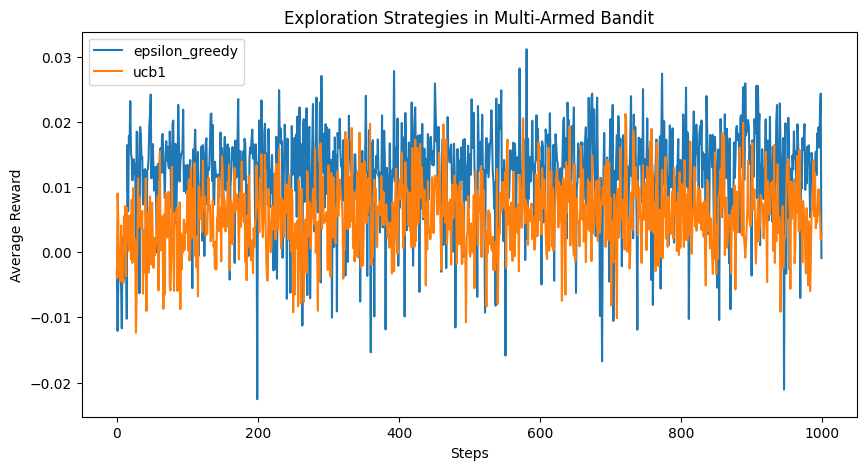

In [7]:
print("Junaid Shaikh  | 48 | 221A052")
#Plot the results
plt.figure(figsize=(10,5))
for strategy, rewards in results.items():
  plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.title("Exploration Strategies in Multi-Armed Bandit")
plt.show()

Observations

Initial Phase (First 100 Steps)

* Both strategies start with low rewards and improve over time.
* UCB1 shows a faster initial learning rate, meaning it finds better arms more quickly.

Middle Phase (100 - 500 Steps)

*  UCB1 consistently outperforms Epsilon-Greedy with slightly higher rewards.
* Epsilon-Greedy fluctuates more, as it keeps exploring randomly with probability ε.

Final Phase (500 - 1000 Steps)


* UCB1 stabilizes at a slightly higher average reward.
* Epsilon-Greedy keeps fluctuating due to its continued exploration.
*   UCB1's confidence-based exploration leads to better long -term exploitation










Conclusion
*   For short duration either of the algorithms can be used
*   For long term UCB1 is most appropriate

